# Forecasting with ARIMA

This is a mathematically rigorous and practical introduction to the ARIMA model. I discuss the following topics, with bare-metal implementations:
* AR, MA and I definition.
* How to identify AR and MA orders: the ACF and PACF graphs.
* How to identify stationarity: the Dickey-Fuller and Augmented DF test.
* Conclusions.


We will start by decomposing the meaning of ARIMA (Autoregressive Integrated Moving Averages). For that matter, let $X\colon \mathbb Z_{\ge 0} \to \mathbb R$ be a time series.

## Autoregressive (AR)

The time series is said to be autoregressive of order $p$ if
$$
    X(t) = e(t) + \sum_{k=1}^{p} a_k X(t-k),
$$
where $e\colon \mathbb Z_{+} \to \mathbb R$ is the error function, usually assume to be a mean zero gaussian with variance $\sigma^2$. If we let $B$ be the left-shift or backward operator, that is, $B X(t) = X(t-1)$, then
$$
    (1 - \sum_{k=1}^{p} a_k B^k) X(t) = e(t).
$$

## Moving Averages (MA)

The time series is said to be on moving averages of order $q$ if
$$
    X(t) = e(t) - \sum_{k=1}^{q} b_k e(t-k).
$$
That is, $X(t)$ can be reconstructed by a series of shocks or jumps. Usually, the $e(t)$'s are assumed independent and normally distributed. In particular, this makes $X$ stationary.

## Mixed models and relationship between AR and MA

Denote by $\alpha(B) = 1 - \sum_{k=1}^{p} a_k B^{k}$ and $\beta(B) = 1 + \sum_{k=1}^q b_k B^k$, so that the AR and the MA model can be writen succintly as:
$$
    \alpha(B) X(t) = e(t) \qquad X(t) = \beta(B) e(t).
$$
Hence, if we assume that $X(t)$ fits both models, we get that $\alpha(B)^{-1} \approx \beta(B)$ and $\beta(B)^{-1} = \alpha(B)$.

**Theorem 1.** For $\alpha(B)$ to is invertible, it is a necessary condition that the zeroes of $\alpha(z)$ lie outside the unit complex disc.
In particular, if $\alpha$ is invertible the AR model is stationary.

<span style="color: blue">

**Proof**
Suppose that $\alpha(z) = (z-z_1)\cdots(z-z_n)$, where the $z_i$ are the zeroes of the polynomial. For $n=1$ we get that
$$
    \alpha(z)^{-1} = (z-z_1)^{-1} = - z^{-1} \sum_{k\ge 0} (z/z_1)^{k}
$$
Since the operator norm of $B$ is one (see **Lemma 1.** below), we need this series to converge for all $|z| < 1$. The last condition fails if $|z_1| < 1$ since $|z/z_1|^k = (|z|/|z_1|)^k$ is greater than $1$ for $1 > |z| > |z_1|$.
Next, suppose $n\ge 2$ and that $|z_1| < 1$. Then,
$$
    \alpha(z)^{-1} = (z-z_1)^{-1} \cdots (z-z_n)^{-1}
$$
and the same argument applies.

</span>

**Lemma 1.** The operator norm of $B$, defined as $|B| = \sup |B(Y)|_{\infty}$ over all functions $Y\colon \mathbb Z_{+} \to \mathbb R$ is one.

<span style="color: blue">

**Proof**
Recall that $|Y|_{\infty} = \sup_{t\in \mathbb Z_{+}} |Y(t)|$. Hence, taking $Y = 1$ for all times gives that $|B| \ge 1$. Clearly $|B| \le 1$, since otherwise there would exists a function $Y$ taking a value greater than $1$ and therefore it cannot appear in the supremum.

</span>

Below there are some plots for a AR, MA and ARMA models of order 2.

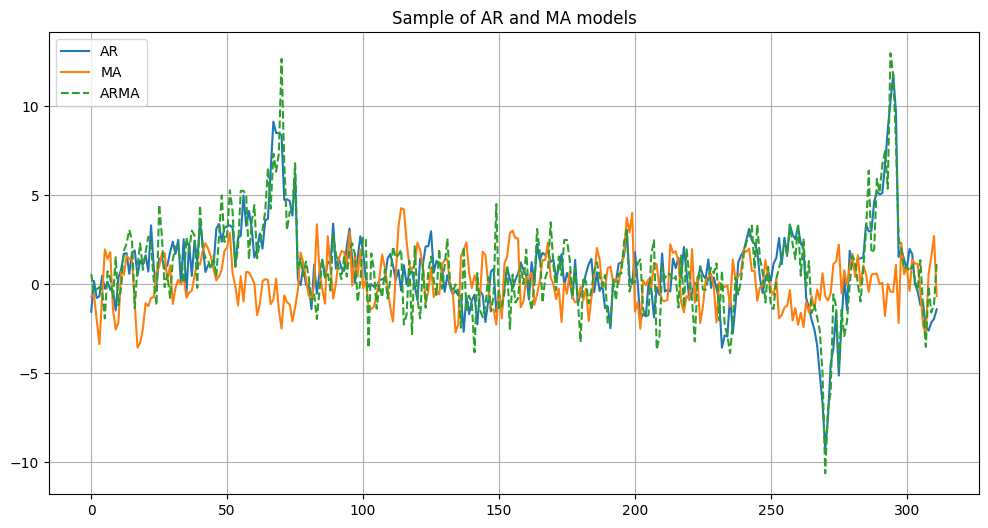

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

p, q = 2, 2
N = 12*26

#  AR
e_AR = np.random.randn(N)
a = np.random.rand(N)

X_AR = np.zeros(N)
X_AR[0] = 0.5

#  MA
e_MA = np.random.randn(N)
b = np.random.rand(N)
X_MA = np.zeros(N)

#  ARMA
e_ARMA = np.random.randn(N)
X_ARMA = np.zeros(N)

for i in range(N):
    X_ARMA[i] = e_ARMA[i] + X_AR[i-p:i] @ a[i-p:i] - e_ARMA[i-q:i] @ b[i-q:i]
    X_AR[i] = X_AR[i-p:i] @ a[i-p:i] + e_AR[i]
    X_MA[i] = e_MA[i-q:i] @ b[i-q:i] + e_MA[i]

plt.figure(figsize=(12, 6))
plt.title('Sample of AR and MA models')
plt.plot(X_AR, label='AR')
plt.plot(X_MA, label='MA')
plt.plot(X_ARMA, '--', label='ARMA')
plt.legend()
plt.grid(True)
plt.show();

After some trials, we are convinced that MA models are oscillating around zero and AR models peaks a lot following the local trend, and the mixture seems to make small corrections.

For reference, here is the historic close price of a security that we'll be studying (LATAM, a chilean airline). You can see the similarity in shape with the ARMA model and understand that it may be a useful tool in analyzing time series.

Using cache data

Data shape: (312, 1)


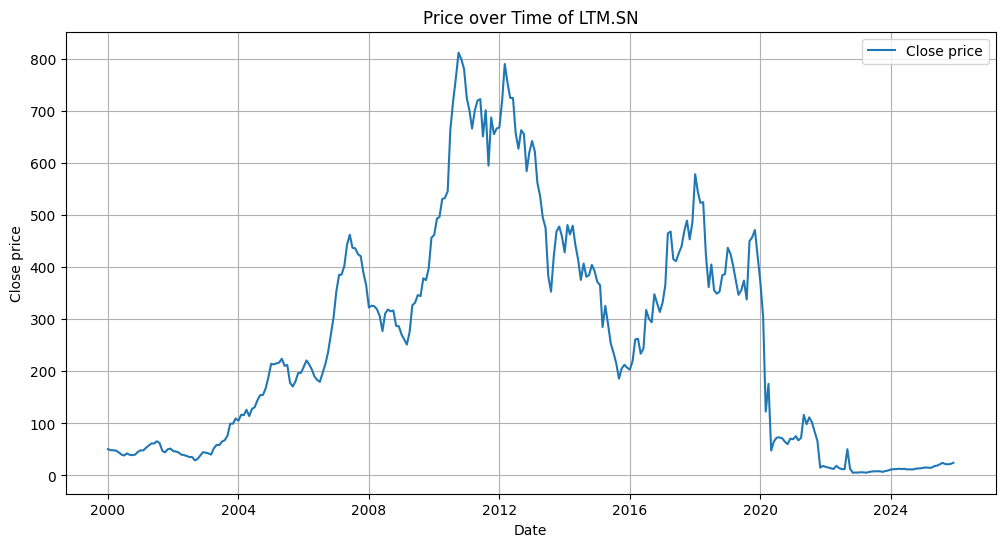

In [2]:
from pathlib import Path
import yfinance as yf


data_path = Path('Datasets')
data_path.mkdir(exist_ok=True)

actor = 'LTM.SN'

data_path = data_path / actor
if data_path.exists():
    print('Using cache data')
    import pandas as pd
    df = pd.read_csv(data_path, index_col=0, parse_dates=True)
else:
    df = yf.download(actor, start='2000-01-01', end='2025-12-31', interval='1mo')['Close']
    df.to_csv(data_path)

print(f"\nData shape: {df.shape}")

plt.figure(figsize=(12, 6))
plt.plot(df.index, df, label='Close price')
plt.title(f'Price over Time of {actor}')
plt.xlabel('Date')
plt.ylabel('Close price')
plt.legend()
plt.grid(True)
plt.show();

Recall that MA is always stationary. If $\alpha$ fails to be invertible then AR is non-stationary. It is pretty clear that if a zeroes $\alpha$ lies inside the unit circle the process grows uncontrolled (check this!). The next case is that we have a number $d$ of zeroes on the unit circle, in that case, $\alpha(B) = \tilde \alpha(B) (1-B)^{d}$ and we can write the ARMA model as
$$
    \tilde \alpha(B) (1-B)^{d} X(t) = e(t).
$$
Write $\nabla^d = (1 - B)^{d}$ for the $d$-difference operator, acting as
$$
\left\{
\begin{aligned}
    \nabla X(t) &= X(t) - X(t-1) \\
    \nabla^d X(t) &= \sum_{k=1}^{d} \binom{d}{k} (-1)^k X(t-k)
\end{aligned}
\right.
$$
and denoting $W(t) = \nabla^d X(t)$ we can write a stationary process on $W(t)$,
$$
    \tilde\alpha(B) W(t) = e(t).
$$

## Integrated (I)

Since $W(t) = \nabla^d X(t)$, it holds that $\nabla^{-d} W(t) = X(t)$. Notice that
$$
    \nabla^{-1} W(t) = (1-B)^{-1} W(t) = \sum_{k=0}^{\infty} W(t-k),
$$
and
$$
    \nabla^{-2} 
    = \sum_{k\ge 0} (k+1) B^{k}.
$$
Expressions can be obtained for the general case of $\nabla^{-d}$, the point is that all these operators ends up weight-summing values of the time series, and hence, $X(t)$ is constructed by weight-summing the values of a stationary process (recall that $\tilde \alpha(B) W(t) = e(t)$). In the continuous case, the time series would be a weighted integral $X(t) = \int_{s\le t} c(s) W(s) \, ds$, thus "integrated".


## General ARIMA

We have defined the ARMA($p,d,q$) process, where $p$ is the number of steps to look back at $X$, $q$ the number of steps to look back at $e$ and $d$ is the non-stationarity degree. In the general case, the ARIMA model reads
$$
    \tilde \alpha(B) \nabla^d X(t) = b_0 + \beta(B) e(t)
$$
where $\tilde \alpha(B) = 1 - \sum_{k=1}^{p} a_k B^k$ and $\beta(B) = 1 - \sum_{k=1}^{q} b_k B^k$, both invertible with zeroes outside the unit disc. In total, the model has $p+q+2$ parameters accounting for the variance of the error $e$ and the constant $b_0$.

> The constant $b_0$ allows for deterministic linear trends. We take $b_0=0$, expressing no deterministic linear trends. For details see [1].

# How to recognize stationary processes

If $X(t)$ follows a MA model, the jump between $X(t)$ and $X(t-k)$ follows a gaussian distribution and the covariance between $X(t)$ and $X(t-k)$ vanishes rapidly as $k \to \infty$. Suppose we are in a fix time $t$ and denote by $\tilde \mu = \frac{1}{t} \sum_{k\le t} X(k)$ the empirical mean so far and by
$$
    \gamma_k = \mathbb E \lbrace (X(t) - \tilde \mu) (X(t-k) - \tilde \mu) \rbrace
$$
the empirical autocovariance function centered at $t$. The autocorrelation is defined as
$$
    \rho_k = \frac{\gamma_k}{\gamma_0}.
$$
Thus, $\rho_0=1$ and $\rho_k \le 1$ for $k\ge 1$.

> Rmk. If the process is stationary, $\gamma_{-k} = \gamma_{k}$.

We expect $\gamma_k$, and hence, $\rho_k$ to drop at the order of the MA process. The following plots show the differences between MA processes and other non-stationary process. The acf graphs for AR, ARMA and a real time series are clearly different from a MA acf graph, where a huge drop in correlation can be observe around the $q$ lag.

In [3]:
# for validation purposes
from statsmodels.tsa.stattools import acf as true_acf, pacf as true_pacf

In [4]:
def acf(X, lag=None):
    ''' computes the (sample) autocorrelation function up to the specified lag '''
    mean = X.mean()
    X0 = X - mean
    c = np.zeros(lag+1)  # covariance coefficients
    c[0] = X0 @ X0
    for k in range(lag):
        c[k+1] = X0[k+1:] @ X0[:-(k+1)]
    c = c / X.size
    return c / c[0]

SAME AS STATSMODELS? True
SAME AS STATSMODELS? True
SAME AS STATSMODELS? True
SAME AS STATSMODELS? True


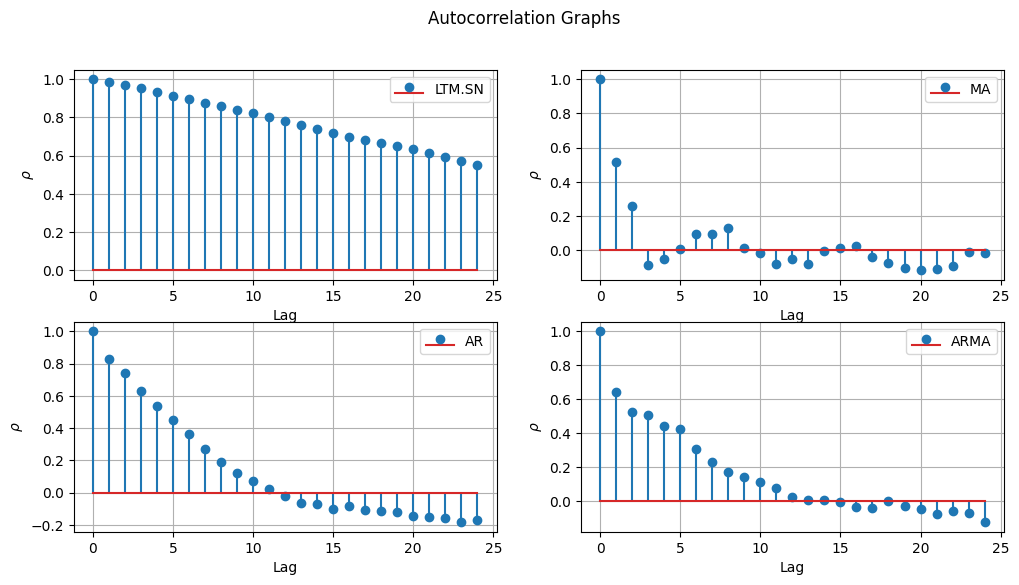

In [5]:
fig, ax = plt.subplots(figsize=(12, 6), ncols=2, nrows=2)
ax = np.array(ax).ravel()

fig.suptitle('Autocorrelation Graphs')

for i, (name, series) in enumerate([
    (actor, df.to_numpy().ravel()),
    ('MA', X_MA),
    ('AR', X_AR),
    ('ARMA', X_ARMA),
]):
    rho = acf(series, lag=12*2)
    true_rho = true_acf(series, nlags=12*2)

    print('SAME AS STATSMODELS?', np.all(np.isclose(rho, true_rho)))
    
    ax[i].stem(rho, label=name)
    ax[i].set_xlabel('Lag')
    ax[i].set_ylabel(r'$\rho$')
    ax[i].legend()
    ax[i].grid(True)

plt.show();

Is this behavior enough to state that the `actor`, AR and ARMA time series do not exhibit stationarity? Let us simplify the analysis and focus on the AR process. We saw already that if $\alpha$ is invertible, the series is stationary. Hence, we should check if $\alpha$ has a unit root, the problem though is that we do not know $\alpha$!

## ADF test

The Augmented Dickey-Fuller test inform us whether $\alpha$ has a unit complex root, and it is therefore non-stationary. Let's start with the simplest case (the Dickey-Fuller test [3], [4]).

**Dickey-Fuller test**

Suppose that
$$
    X(t) = a X(t-1) + e(t),
$$
Then, $\alpha(z) = (1 - a z)$. This polynomial has a root at $z = 1/a$, thus $a=1$ yields a unit complex root.

Denote by $\vec X(t) = (X(1), \ldots, X(t))^{T}$ and $\vec X(t-1) = (X(0), \ldots, X(t-1))^T$, then the optimal mean square error choice of $a$ is
$$
    \hat a = \frac{\vec X(t-1)^T \vec X(t)}{\|\vec X(t-1) \|_2^2}.
$$
> This can be seen by solving the first order conditions of $\sum (X(t) - \hat a X(t-1))^2$.

Now $\hat a$ is a random variable with its own distribution depending on $X$, at the same time $X$ depends on the actual value of $a$. Thus, we may test how likely is to observe $\hat a$ given that $a=1$. Notice that
$$
\begin{aligned}
    \hat a 
    &= (\vec X(t-1)^T \cdot \vec X(t-1))^{-1} \vec X(t-1)^T \vec X(t)
    \\&= (\vec X(t-1)^T \cdot \vec X(t-1))^{-1} \vec X(t-1)^T (a \vec X(t-1) + \vec e(t))
    \\&= a + (\vec X(t-1)^T \cdot \vec X(t-1))^{-1} \vec X(t-1)^T \vec e(t)
\end{aligned}
$$
distributes normally with mean $a$ and variance depending on $\vec X(t-1)$ and $\vec e(t) = (e(1), \ldots, e(t))^T$. In particular, we can use the following test statistic to test for the null hypothesis that $a = 1$:
$$
    \tau
    = \frac{\hat a - 1}{s.e.(\hat a)}
    = \frac{\hat a - 1}{\sqrt{\mathbb V(\hat a - a)}}.
$$
Observe that
$$
    \mathbb V(\hat a - a)
    = 
    (\vec X(t-1)^T \cdot \vec X(t-1))^{-1} \vec X(t-1)^T
    \mathbb V(\vec e(t))
    \vec X(t-1) (\vec X(t-1)^T \cdot \vec X(t-1))^{-T} 
$$
since $\vec e(t) \approx \vec X(t) - \hat a \vec X(t-1) \sim \textrm{NID}(0, \sigma^2)$ we can approximate the variance as
$$
    \mathbb V(\vec e(t)) 
    =
    \mathbb E \lbrace \vec e(t)^2 \rbrace
    =
    \mathbb E\lbrace \| \vec X(t) - \hat a \vec X(t-1) \|_2^2 \mathbf 1 \rbrace.
$$
Thus, with the unbiased estimator
$$
    \hat s^2 = \frac{\| \vec X(t) - \hat a \vec X(t-1) \|_2^2}{t-1} \approx \mathbb V(e(t))
$$
the estimate for $\mathbb V(\hat a - a)$ reads:
$$
    \hat v = \hat s^2 (\vec X(t-1)^T \cdot \vec X(t-1))^{-T} = \hat s^2 (\vec X(t-1)^T \cdot \vec X(t-1))^{-1}.
$$
In all, the t-test estimator reads:
$$
    \hat \tau = \frac{\hat a - 1}{\sqrt{\hat s^2 (\vec X(t-1)^T \cdot \vec X(t-1))^{-1}}}.
$$
We now inspect the distribution of $\hat \tau$ under $a = 1$.

In [6]:
''' This snippet computes the distribution for the hat tau statistic under a=1 '''

#  number of samples
m = 50_000
#  length of the series
n = 300

rng = np.random.default_rng(8918)
hat_tau = np.zeros(m)

for k in range(m):
    #  Generate process
    e = rng.standard_normal(size=n)
    Xt = np.zeros(n)
    
    for i in range(1, n):
        Xt[i] = Xt[i-1] + e[i]

    #  Compute Estimator
    Xbt_nsq = Xt[1:-1] @ Xt[1:-1]
    hat_a = Xt[1:-1] @ Xt[2:] / Xbt_nsq
    s_sq = np.linalg.norm(Xt[2:] - hat_a * Xt[1:-1])**2 / (n-2)
    hat_tau[k] = (hat_a - 1) / np.sqrt(s_sq / Xbt_nsq)

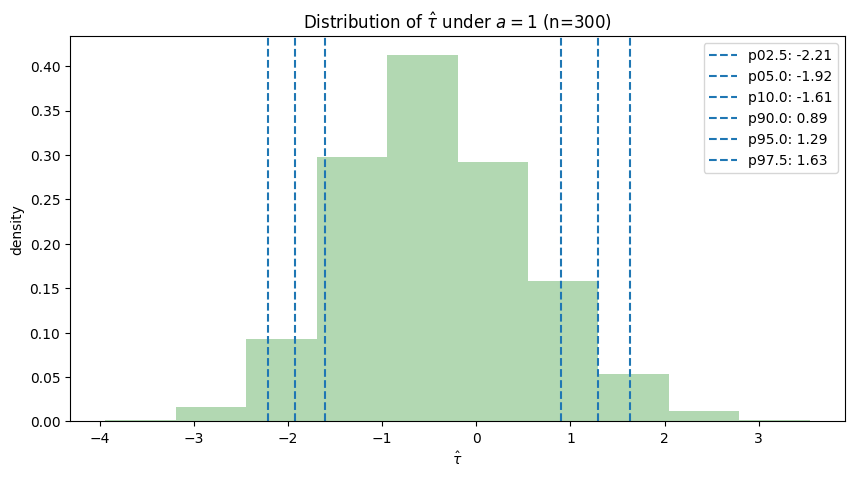

In [7]:
beta = [2.5, 5, 10, 90, 95, 97.5]
alpha = np.percentile(hat_tau, beta)

plt.figure(figsize=(10, 5))
plt.title(fr'Distribution of $\hat \tau$ under $a=1$ (n={n})')

plt.hist(hat_tau, color='green', alpha=0.3, density=True)
plt.xlabel(r'$\hat \tau$')
plt.ylabel('density')

for a, b in zip(alpha, beta):
    plt.axvline(a, linestyle='--', label=f'p{b:04.1f}: {a:04.2f}')

plt.legend()
plt.show()

In summary, for a given time series that we think fits an AR$(1)$ model with $a=1$, we compute $\hat \tau$ and if, for example, $\hat \tau \not \in (-1.92, 1.29)$ then it is unlikely that $a=1$ and we reject the hypothesis that $a=1$ with 10\% statistical significancy or 90\% confidence.

> Since we are assuming the series does not follow an exponential trend, we know that $a \le 1$, thus, we can check the test only for the one sided left tail that concerns with negative values.

**Augmented Dickey-Fuller test**

Consider the general AR($p$) case
$$
    X(t) = \sum_{k=1}^{p} a_k X(t-k) + e(t)
    \qquad
    e(t) \sim \textrm{NID}(0, \sigma^2).
$$
The polynomial is $\alpha(z) = 1 - a_1 z - a_2 z^2 - \cdots - a_k z^k$. We want to test if $\alpha(z)$ has a **unique** unit root. Since complex roots come in pairs (if $z$ is a root, its conjugate it is a root as well), it must be the case that $z = 1$ or $z=-1$. As a consequence, we obtain the following conditions:
$$
    \alpha(z) \textrm{ has a unique unit real root if }
    1 = a_1 + \ldots + a_k
    \textrm{ or }
    1 = -(a_1 + \ldots + a_k).
$$
Up to a change of sign, we define the null hypothesis as $H_0:\, a_1 + \ldots + a_k - 1 = 0$ and we will test it using the t-statistic
$$
    \hat\rho = \frac{(\hat a_1 + \cdots + \hat a_k) - 1}{s.e.(\hat a_1 + \cdots + \hat a_k)}
$$
where $\hat a_i$ are computed using OLS.

<span style="color:red">TODO: compute distribution of $\hat \rho$</span>

In [1]:
def adf_test(X, p):
    pass

# How to identify $p$ in an AR time series

If $X(t) = aX(t-1) + e(t)$, then clearly $X(t)$ also depends on $X(t-2)$ by simple substitution. The idea is to reduce the echo of past events that are not directly or strongly influencing $X(t)$.

Recall that a AR($p$) time series adopts the following form:
$$
    X(t) = e(t) + \sum_{j=1}^{p} a_j X(t-j).
$$
Hence,
$$
    X(t) X(t-k) = e(t) X(t-k) + \sum_{j=1}^{p} a_j X(t-j) X(t-k)
$$
and
$$
    \mathbb E \lbrace X(t) X(t-k) \rbrace
    =
    \mathbb E \lbrace e(t) X(t-k) \rbrace + \sum_{j=1}^{p} a_j \mathbb E \lbrace X(t-j) X(t-k) \rbrace.
$$
By assumption, $\mathbb E\lbrace e(t) X(t-k) \rbrace = 0$ for $k\ge 1$. As a consequence, it holds that
$$
\left\{
\begin{aligned}
    \gamma_0 &= \mathbb E \lbrace e(t) X(t) \rbrace + \sum_{j=1}^{p} a_j \gamma_{j}
    \\
    \gamma_k &= \sum_{j=1}^{p} a_j \gamma_{k-j}
    \qquad k=1,\dots,p
\end{aligned}
\right.
$$
We can estimate the $\gamma_k$ values, thus, to obtain the $a_k$'s we need to solve a system of $p$ equations in $p$ unknowns. In matrix form we got the system
$$
    \underbrace{
    \begin{bmatrix}
        \gamma_{0} & \gamma_{-1} & \cdots & \gamma_{1-p}\\
        \gamma_{1} & \gamma_{0} & \ddots & \vdots\\
        \vdots & \ddots & \ddots & \vdots\\
        \gamma_{p-1} & \gamma_{p-2} & \cdots & \gamma_{0} 
    \end{bmatrix}
    }_{\mathbf \Gamma}
    \underbrace{
    \begin{bmatrix}
        a_1 \\ a_2 \\ \vdots \\ a_{p-1} \\ a_p
    \end{bmatrix}
    }_{\mathbf a}
    =
    \begin{bmatrix}
        \gamma_1\\ \gamma_2 \\ \vdots \\ \gamma_{p-1} \\ \gamma_p
    \end{bmatrix}.
$$

Summarizing, **IF** the time series fits the AR($p$) model and we compute the coefficients $\mathbf a^{(k)}$ for $k=1,\ldots,\infty$, then, for $k>p$ we should see $\mathbf a^{(k)}_k$ become negligible noise. Hence, we **partially** fit the series and plot the last coefficient.

> Question: Can we just estimate $a$ using ordinary least squares?

In [8]:
def pacf(X, max_lag=None):
    ''' computes the (sample) partial autocorrelation function up to the specified lag '''
    X0 = X - X.mean()
    pacf = [1.0]
    for lag in range(1, max_lag+1):
        #  Compute autocovariance
        c = np.zeros(lag+1)
        c[0] = X0 @ X0 / X.size
        for k in range(1, lag+1):
            c[k] = X0[k:] @ X0[:-k] / X.size
    
        #  Solve for the a's
        a = sp.linalg.solve_toeplitz(c[:-1], c[1:])

        pacf.append(a[-1])
    
    return np.array(pacf)

IS VALID False WITH DIFFERENCE 0.039506900930170175
IS VALID False WITH DIFFERENCE 0.0035556724283538066
IS VALID False WITH DIFFERENCE 0.00843212872987012
IS VALID False WITH DIFFERENCE 0.008668477700159771


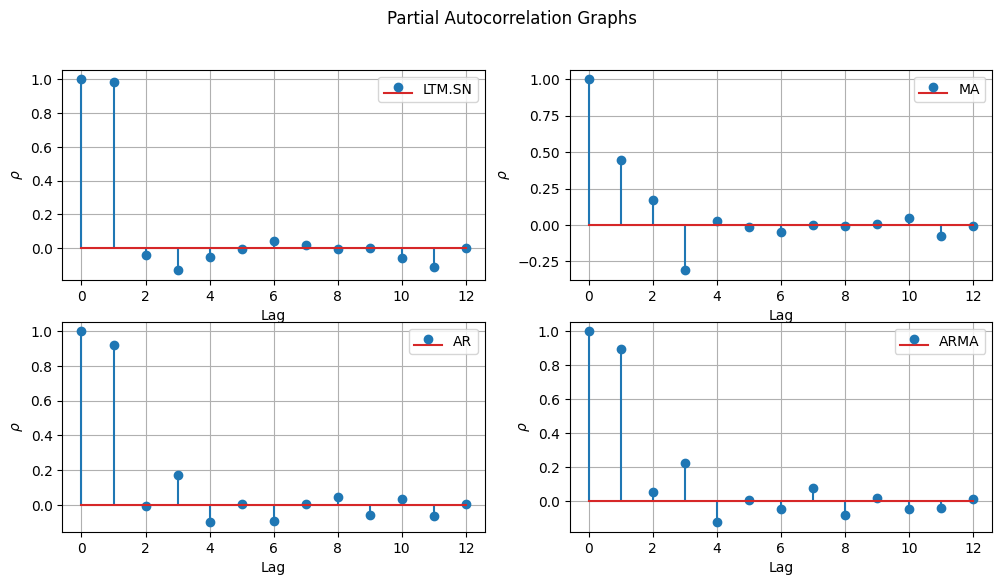

In [9]:
fig, ax = plt.subplots(figsize=(12, 6), ncols=2, nrows=2)
ax = np.array(ax).ravel()

fig.suptitle('Partial Autocorrelation Graphs')

for i, (name, series) in enumerate([
    (actor, df.to_numpy().ravel()),
    ('MA', X_MA),
    ('AR', X_AR),
    ('ARMA', X_ARMA),
]):
    rho = pacf(series, max_lag=12)
    rho_true = true_pacf(series, nlags=12, method='yw')

    print('IS VALID', np.all(np.isclose(rho, rho_true)), 'WITH DIFFERENCE', np.abs(rho-rho_true).max())
    
    ax[i].stem(rho, label=name)
    # ax[i].stem(rho_true, 'r--', label='true')
    ax[i].set_xlabel('Lag')
    ax[i].set_ylabel(r'$\rho$')
    ax[i].legend()
    ax[i].grid(True)

plt.show();

The plot suggest that `actor` fits an AR model with $p=2$. Now test for stationarity

In [2]:
# adf_test(df, 2)

# ARIMA Forecasting

<span style="color: red">TODO</span>

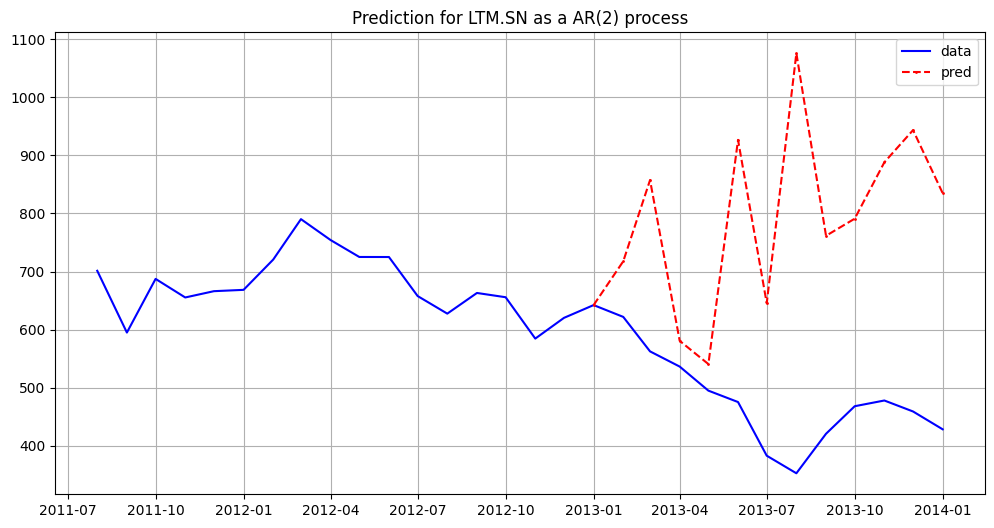

In [10]:
last_time = df.shape[0] // 2 if df.shape[0] % 2 else (df.shape[0]+1)//2
Y = df.to_numpy().ravel()

X = np.zeros(df.shape[0])
X[:last_time+1] = Y[:last_time+1].copy()

L = 12

p, q = 2, 0

for l in range(1, L+1):
    mu = X[:last_time + l].mean()
    X0 = X[:last_time + l] - mu

    #  Compute correlation
    c = np.zeros(p + 1)
    c[0] = X0 @ X0 / (last_time + l)
    for k in range(1, p + 1):
        c[k] = X0[k:] @ X0[:-k] / X.size

    #  Solve for AR fit
    a = sp.linalg.solve_toeplitz(c[:-1], c[1:])

    #  Compute prediction
    sigma = np.sqrt(c[0] - a @ c[1:])
    X[last_time + l] = mu + a @ X[last_time + l - p: last_time + l] + np.random.normal(scale=sigma)


start_time, end_time = last_time-L-5, last_time+L+1

plt.figure(figsize=(12, 6))
plt.title(f'Prediction for {actor} as a AR({p}) process')
plt.plot(df.index[start_time:end_time], Y[start_time:end_time], 'b', label='data')
plt.plot(df[last_time:end_time].index, X[last_time:end_time], 'r--o', markersize=1, label='pred')
plt.grid(True)
plt.legend()
plt.show()

# Conclusions



# References

1. Box, G., Jenkins, G., Reinsel, G., & Ljung, G. (5th ed.). (1994). Time series analysis: Forecasting and control. Wiley.

2. Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with python. Proceedings of the 9th Python in Science Conference.

3. Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for autoregressive time series with a unit root. Journal of the American Statistical Association, 74(366a), 427-431.

4. Dickey, D. A. (1976). ESTIMATION AND HYPOTHESIS TESTING IN NONSTATIONARY TIME SERIES. Iowa State University, Ph.D. thesis.

5. Panaretos, V. (2010). Statistics for mathematicians. Springer.

6. Anna Mikusheva (2007). 14.384 Time Series Analysis_Lecture 17: unit roots